In [460]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn
import nltk
import re

In [461]:
#if emoji and other language is present we have to use  encoding='ISO-8859-1'
df=pd.read_csv('twitter_validation.csv',header=None) 
df

,0,1,2,3
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [462]:
df.head()

,0,1,2,3
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...


In [463]:
df.tail()

,0,1,2,3
995,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.
999,6960,johnson&johnson,Neutral,Johnson & Johnson to stop selling talc baby po...


In [464]:
df.columns=['id','media','target','text']
df

,id,media,target,text
0,3364,Facebook,Irrelevant,I mentioned on Facebook that I was struggling ...
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
...,...,...,...,...
995,4891,GrandTheftAuto(GTA),Irrelevant,⭐️ Toronto is the arts and culture capital of ...
996,4359,CS-GO,Irrelevant,tHIS IS ACTUALLY A GOOD MOVE TOT BRING MORE VI...
997,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [465]:
df.isna().sum()

id        0
media     0
target    0
text      0
dtype: int64

In [466]:
df.dtypes

id         int64
media     object
target    object
text      object
dtype: object

In [467]:
df1=df['media'].value_counts()
df1

media
RedDeadRedemption(RDR)               40
johnson&johnson                      39
FIFA                                 38
PlayerUnknownsBattlegrounds(PUBG)    38
LeagueOfLegends                      37
ApexLegends                          36
TomClancysRainbowSix                 35
Nvidia                               35
GrandTheftAuto(GTA)                  35
Amazon                               34
Fortnite                             34
Facebook                             33
PlayStation5(PS5)                    33
AssassinsCreed                       33
Borderlands                          33
Overwatch                            32
Hearthstone                          32
Verizon                              32
CS-GO                                32
CallOfDuty                           31
Cyberpunk2077                        30
WorldOfCraft                         30
MaddenNFL                            29
Microsoft                            28
Dota2                             

In [468]:
df2=df['target'].value_counts()
df2

target
Neutral       285
Positive      277
Negative      266
Irrelevant    172
Name: count, dtype: int64

<BarContainer object of 4 artists>

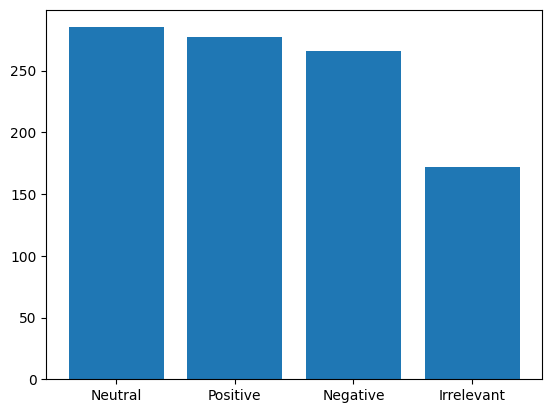

In [469]:
plt.bar(df2.index,df2.values)

In [470]:
df3=df['text'].value_counts()
df3

text
Wow                                                                                                                                                                                                                                                   2
I mentioned on Facebook that I was struggling for motivation to go for a run the other day, which has been translated by Tom’s great auntie as ‘Hayley can’t get out of bed’ and told to his grandma, who now thinks I’m a lazy, terrible person 🤣    1
Update: I actually finished Odyssey. I wish the three-ponged questline structure was communicated a bit more clearly but that game is a lot of fun once it hits its stride. twitter.com/iv_javy/status…                                               1
Know Your History...unless it involves China....because like....we have investors and shit...                                                                                                                                                         1
Con

In [471]:
#df = df[df['target'] != 'Irrelevant']
#or else
df.drop(df.index[(df['target']=='Irrelevant')],axis=0,inplace=True)
df

,id,media,target,text
1,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
2,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
3,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
4,4433,Google,Neutral,Now the President is slapping Americans in the...
5,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...,...,...
993,314,Amazon,Negative,Please explain how this is possible! How can t...
994,9701,PlayStation5(PS5),Positive,Good on Sony. As much as I want to see the new...
997,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
998,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [472]:
df.reset_index(drop=True,inplace=True)
df

,id,media,target,text
0,352,Amazon,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,8312,Microsoft,Negative,@Microsoft Why do I pay for WORD when it funct...
2,4371,CS-GO,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,4433,Google,Neutral,Now the President is slapping Americans in the...
4,6273,FIFA,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...,...,...
823,314,Amazon,Negative,Please explain how this is possible! How can t...
824,9701,PlayStation5(PS5),Positive,Good on Sony. As much as I want to see the new...
825,2652,Borderlands,Positive,Today sucked so it’s time to drink wine n play...
826,8069,Microsoft,Positive,Bought a fraction of Microsoft today. Small wins.


In [473]:
df.drop(columns=['id','media'],axis=1,inplace=True)
df

,target,text
0,Neutral,BBC News - Amazon boss Jeff Bezos rejects clai...
1,Negative,@Microsoft Why do I pay for WORD when it funct...
2,Negative,"CSGO matchmaking is so full of closet hacking,..."
3,Neutral,Now the President is slapping Americans in the...
4,Negative,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...
823,Negative,Please explain how this is possible! How can t...
824,Positive,Good on Sony. As much as I want to see the new...
825,Positive,Today sucked so it’s time to drink wine n play...
826,Positive,Bought a fraction of Microsoft today. Small wins.


In [474]:
df['target'] = df['target'].map({'Positive': 1, 'Negative': -1, 'Neutral': 0})
df

,target,text
0,0,BBC News - Amazon boss Jeff Bezos rejects clai...
1,-1,@Microsoft Why do I pay for WORD when it funct...
2,-1,"CSGO matchmaking is so full of closet hacking,..."
3,0,Now the President is slapping Americans in the...
4,-1,Hi @EAHelp I’ve had Madeleine McCann in my cel...
...,...,...
823,-1,Please explain how this is possible! How can t...
824,1,Good on Sony. As much as I want to see the new...
825,1,Today sucked so it’s time to drink wine n play...
826,1,Bought a fraction of Microsoft today. Small wins.


In [475]:
df.dtypes

target     int64
text      object
dtype: object

In [476]:
nltk.download('stopwords')
nltk.download('punkt_tab')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\vilas\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!
[nltk_data] Downloading package punkt_tab to
[nltk_data]     C:\Users\vilas\AppData\Roaming\nltk_data...
[nltk_data]   Package punkt_tab is already up-to-date!


True

In [477]:
tweets=df.text
tweets

0      BBC News - Amazon boss Jeff Bezos rejects clai...
1      @Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking,...
3      Now the President is slapping Americans in the...
4      Hi @EAHelp I’ve had Madeleine McCann in my cel...
                             ...                        
823    Please explain how this is possible! How can t...
824    Good on Sony. As much as I want to see the new...
825    Today sucked so it’s time to drink wine n play...
826    Bought a fraction of Microsoft today. Small wins.
827    Johnson & Johnson to stop selling talc baby po...
Name: text, Length: 828, dtype: object

In [478]:
#TOKENIZATION
from nltk.tokenize import TweetTokenizer
tk=TweetTokenizer()
tweets=tweets.apply(lambda x:tk.tokenize(x)).apply(lambda x:' '.join(x))
tweets

0      BBC News - Amazon boss Jeff Bezos rejects clai...
1      @Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking ...
3      Now the President is slapping Americans in the...
4      Hi @EAHelp I ’ ve had Madeleine McCann in my c...
                             ...                        
823    Please explain how this is possible ! How can ...
824    Good on Sony . As much as I want to see the ne...
825    Today sucked so it ’ s time to drink wine n pl...
826    Bought a fraction of Microsoft today . Small w...
827    Johnson & Johnson to stop selling talc baby po...
Name: text, Length: 828, dtype: object

In [479]:
#Remove Special Characters
tweets=tweets.replace('[^a-zA-Z0-9]',' ',regex=True)
tweets

0      BBC News   Amazon boss Jeff Bezos rejects clai...
1       Microsoft Why do I pay for WORD when it funct...
2      CSGO matchmaking is so full of closet hacking ...
3      Now the President is slapping Americans in the...
4      Hi  EAHelp I   ve had Madeleine McCann in my c...
                             ...                        
823    Please explain how this is possible   How can ...
824    Good on Sony   As much as I want to see the ne...
825    Today sucked so it   s time to drink wine n pl...
826    Bought a fraction of Microsoft today   Small w...
827    Johnson   Johnson to stop selling talc baby po...
Name: text, Length: 828, dtype: object

In [480]:
#len(words)>=3
tweets=tweets.apply(lambda x:' '.join([w for w in tk.tokenize(x) if len(w)>=3]))
tweets

0      BBC News Amazon boss Jeff Bezos rejects claims...
1      Microsoft Why pay for WORD when functions poor...
2      CSGO matchmaking full closet hacking truly awf...
3      Now the President slapping Americans the face ...
4      EAHelp had Madeleine McCann cellar for the pas...
                             ...                        
823    Please explain how this possible How can they ...
824    Good Sony much want see the new PS5 what going...
825    Today sucked time drink wine play borderlands ...
826           Bought fraction Microsoft today Small wins
827    Johnson Johnson stop selling talc baby powder ...
Name: text, Length: 828, dtype: object

In [481]:
from nltk.stem import SnowballStemmer
data=SnowballStemmer('english')
tweets=tweets.apply(lambda x:[data.stem(i.lower()) for i in tk.tokenize(x)]).apply(lambda x:' '.join(x))
tweets

0      bbc news amazon boss jeff bezo reject claim co...
1      microsoft whi pay for word when function poor ...
2           csgo matchmak full closet hack truli aw game
3      now the presid slap american the face that rea...
4      eahelp had madelein mccann cellar for the past...
                             ...                        
823    pleas explain how this possibl how can they le...
824    good soni much want see the new ps5 what go ri...
825    today suck time drink wine play borderland unt...
826            bought fraction microsoft today small win
827    johnson johnson stop sell talc babi powder and...
Name: text, Length: 828, dtype: object

In [482]:
from nltk.corpus import stopwords
stop=stopwords.words('english')
tweets=tweets.apply(lambda x:[i for i in tk.tokenize(x) if i not in stop]).apply(lambda x:' '.join(x))
tweets

0      bbc news amazon boss jeff bezo reject claim co...
1      microsoft whi pay word function poor samsungus...
2           csgo matchmak full closet hack truli aw game
3      presid slap american face realli commit unlaw ...
4      eahelp madelein mccann cellar past year littl ...
                             ...                        
823    pleas explain possibl let compani overcharg sc...
824    good soni much want see new ps5 go right much ...
825    today suck time drink wine play borderland sun...
826            bought fraction microsoft today small win
827    johnson johnson stop sell talc babi powder can...
Name: text, Length: 828, dtype: object

#VECTORIZATION

In [503]:
#VECTORIZATION
from sklearn.feature_extraction.text import TfidfVectorizer
vec=TfidfVectorizer()
train_data=vec.fit_transform(tweets)
train_data

<Compressed Sparse Row sparse matrix of dtype 'float64'
	with 10461 stored elements and shape (828, 3763)>

In [484]:
y=df['target'].values
y

array([ 0, -1, -1,  0, -1,  1,  1,  1, -1,  1,  1, -1,  0, -1,  1,  1, -1,
        1, -1, -1,  0, -1,  0,  0, -1, -1,  1,  1, -1,  1, -1,  0,  0,  1,
        0,  1,  0,  0,  0,  1,  0, -1, -1, -1,  0,  1, -1, -1,  1,  1,  1,
        1,  1, -1, -1,  1,  1, -1,  0, -1,  0, -1,  1, -1, -1,  1,  1,  1,
        0,  0,  0,  1,  1,  0,  1,  0, -1, -1,  0,  0, -1,  1, -1, -1, -1,
        0,  1,  0, -1,  1,  1,  0,  1,  0,  1, -1,  0,  0,  0, -1,  0, -1,
        0,  0,  1,  1,  0, -1, -1,  1, -1,  0, -1,  1,  0, -1,  0,  1,  0,
        1,  1,  0,  0,  0,  0,  1,  0,  1,  1, -1,  0,  0,  0,  0, -1,  0,
        1, -1,  0, -1,  0, -1, -1, -1,  1,  1,  1,  0,  0,  1,  0,  0,  0,
        1,  0, -1, -1,  0,  1,  1,  0,  1,  1,  0,  0, -1, -1, -1, -1,  1,
        0,  0,  1,  1,  1,  1, -1,  1,  1,  0, -1, -1, -1,  1,  1, -1, -1,
        1,  1, -1,  1,  1, -1,  1,  0, -1,  0,  0,  1, -1,  1,  1,  0,  1,
       -1, -1,  1,  1,  1,  1,  0,  0,  1, -1,  0,  1,  0, -1,  0,  0, -1,
        1,  1, -1,  0,  1

In [485]:
from sklearn.model_selection import train_test_split
x_train,x_test,y_train,y_test=train_test_split(train_data,y,test_size=0.20,random_state=42)


In [486]:
from sklearn.neighbors import KNeighborsClassifier
knn=KNeighborsClassifier(n_neighbors=7)
knn.fit(x_train,y_train)
y_pred=knn.predict(x_test)
y_pred

array([-1, -1,  1, -1, -1, -1, -1, -1, -1, -1,  1, -1, -1,  1, -1, -1, -1,
       -1, -1, -1, -1,  0,  0,  1, -1,  1, -1, -1, -1,  1, -1,  1, -1, -1,
        1, -1,  1, -1, -1, -1, -1,  1,  0,  1, -1, -1,  1, -1, -1, -1, -1,
       -1, -1, -1, -1,  0,  1, -1,  1,  0,  1, -1,  0,  0, -1,  0,  1,  0,
       -1, -1, -1, -1,  0,  1,  1, -1, -1, -1,  1,  1, -1, -1, -1, -1,  0,
       -1, -1,  1,  1, -1,  1, -1, -1, -1,  0,  0,  0,  0,  0, -1, -1,  1,
        0,  0, -1, -1,  1,  0,  0, -1, -1, -1, -1, -1,  1, -1, -1, -1, -1,
        0, -1,  1, -1,  0,  0,  1, -1, -1,  0, -1, -1, -1, -1, -1, -1,  1,
       -1, -1,  0,  1,  1, -1,  0,  0,  0,  0,  0, -1, -1, -1, -1, -1,  1,
       -1, -1,  0,  1,  0, -1,  0, -1, -1, -1,  1,  1,  0], dtype=int64)

In [487]:
from sklearn.metrics import accuracy_score
score=accuracy_score(y_pred,y_test)*100
score

48.795180722891565

In [488]:
from sklearn.naive_bayes import BernoulliNB
base= BernoulliNB()
base.fit(x_train,y_train)
y_pred1=base.predict(x_test)
y_pred1

array([ 1,  0,  1, -1, -1, -1, -1, -1, -1, -1,  0, -1, -1,  1, -1, -1, -1,
        1, -1,  1,  1, -1,  0,  1,  0,  1,  1, -1,  1,  1,  0,  1, -1,  1,
        1, -1,  0, -1, -1,  1,  1,  1,  1,  1,  1,  1,  0,  1, -1,  1,  0,
       -1, -1,  1,  1,  0, -1,  0,  1, -1,  1, -1,  1,  0,  1,  0,  1,  1,
       -1,  1,  1, -1,  0,  1,  1, -1,  0, -1,  1,  1, -1, -1,  1, -1,  0,
        1,  0,  1,  1,  1, -1, -1,  1, -1,  0,  0,  1,  0,  0,  1,  1,  1,
        1,  0,  1, -1,  1, -1,  0,  1,  1,  0,  1,  1,  1, -1,  1, -1, -1,
        1,  0,  1,  1,  1,  1,  1, -1, -1,  0,  1,  1,  1, -1,  1, -1,  1,
        0,  1,  1,  1,  1, -1,  0, -1,  0,  0,  0, -1,  1, -1,  1,  0,  1,
       -1, -1,  1,  1,  1,  1,  0,  1, -1, -1, -1,  0,  1], dtype=int64)

In [489]:
score2=accuracy_score(y_pred1,y_test)*100
score2

54.21686746987952

In [490]:
from sklearn.svm import SVC
model=SVC()
model.fit(x_train,y_train)
y_pred2=model.predict(x_test)
y_pred2

array([ 1,  0,  1,  0, -1, -1, -1,  0, -1,  0,  0,  1,  0,  1, -1, -1, -1,
        0, -1,  0,  0,  0,  0,  1,  0,  1,  1, -1,  0,  0,  0,  1, -1,  1,
        1, -1,  0, -1,  0,  1,  1,  0,  0,  1,  0,  1,  0,  0,  0,  1,  0,
       -1, -1,  0,  0,  0, -1, -1,  0,  0,  1,  0,  0,  0,  1,  0,  0,  0,
       -1,  1,  1,  0,  0,  1,  1,  0,  0,  0,  1,  1,  0, -1,  0,  0,  0,
        1,  0,  1,  1,  1, -1,  0, -1, -1,  0,  0,  0,  0,  0,  0,  1,  1,
        0,  0,  0, -1,  0,  0,  0,  1,  1,  0,  0,  0,  1, -1,  0,  0, -1,
        0,  0,  0,  1,  0,  1,  1, -1, -1,  0, -1,  1,  0,  0,  0,  1,  1,
        0,  1,  0,  1,  0,  0,  0,  0,  0,  0,  0,  0,  0,  1,  1,  0,  0,
       -1, -1,  0,  1,  0,  0,  0, -1,  0,  0,  0,  1,  0], dtype=int64)

In [491]:
score3=accuracy_score(y_pred2,y_test)*100
score3

52.40963855421686

In [492]:
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(criterion='entropy')
tree.fit(x_train,y_train)
y_pred3=tree.predict(x_test)
y_pred3

array([ 1,  0,  0, -1, -1, -1, -1, -1,  1, -1,  0, -1,  0,  1, -1, -1, -1,
       -1, -1,  0,  1, -1,  0,  0,  1,  1,  1, -1,  0,  1,  0,  1, -1, -1,
        1, -1,  0,  1,  1,  1,  1,  0,  0, -1,  0,  1,  1, -1,  0, -1,  0,
       -1, -1, -1,  0, -1,  0,  0,  0,  0,  1,  0, -1,  0,  1,  0,  1,  0,
       -1,  0,  1,  0,  0, -1,  1,  1, -1, -1,  1,  1,  0, -1, -1,  1,  0,
       -1,  0, -1, -1,  1,  1,  0, -1,  0, -1,  0, -1,  0,  0, -1,  0,  0,
       -1,  1,  0,  1,  0, -1,  0,  1, -1,  0, -1,  0,  0,  1, -1,  1, -1,
        1,  0,  1, -1, -1, -1,  0, -1, -1, -1,  0,  0,  1, -1,  0,  1, -1,
       -1, -1, -1,  1, -1,  0,  1, -1,  0,  1, -1,  0,  0, -1,  0,  0,  1,
       -1, -1, -1, -1,  1,  1, -1, -1, -1,  1,  1,  1,  0], dtype=int64)

In [493]:
score4=accuracy_score(y_pred3,y_test)*100
score4

45.78313253012048

In [494]:
df1=pd.DataFrame({'Model_Name':['KNN','BASE','SVM','Decision_Tree'],
                  'Score':[score,score2,score3,score4]})
df1

,Model_Name,Score
0,KNN,48.795181
1,BASE,54.216867
2,SVM,52.409639
3,Decision_Tree,45.783133


<BarContainer object of 4 artists>

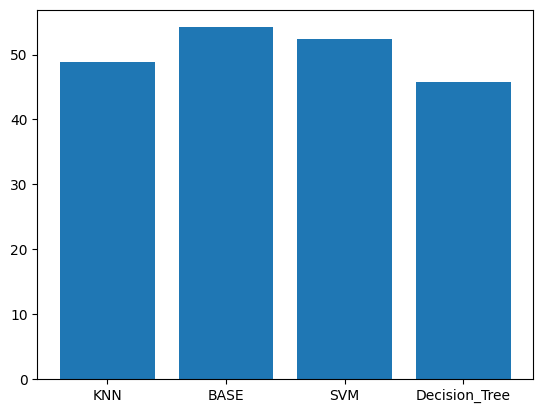

In [495]:
plt.bar(df1.Model_Name,df1.Score)

In [ ]:
from sklearn.pipeline import Pipeline
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.svm import SVC

model = Pipeline([
    ('vectorizer', CountVectorizer()),
    ('classifier', SVC())
])

model.fit(tweets, y)

model.predict(['The movie is very good'])

array([1], dtype=int64)